In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import math
from pathlib import Path

import numpy as np

import dev
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from IPython.display import display
from matplotlib.patches import Circle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from richio.plots import scalar_map

REPO = Path("/home/hey4/rich_tde")
SHOCK_ROOT = REPO / "data/processed/ShockFinderEdissSelection/analysis/zoom-shocks"
OUTPUT_ROOT = SHOCK_ROOT / "presentation/nozzle"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

SNAPSHOTS = {"1e4": 77, "1e5": 161, "1e6": 850}
ORBIT_S_SHIFT_RSUN = {"1e4": 4.0, "1e5": 3.0, "1e6": 120.0}
XY_CACHES = {
    "1e4": REPO / "data/processed/NozzleZoomSlices/1e4/grids/nozzle_zoom_snap_0077_768.npz",
    "1e5": REPO / "data/processed/NozzleZoomSlices/1e5/grids/nozzle_zoom_snap_0161_768.npz",
    "1e6": REPO / "data/processed/NozzleZoomSlices/1e6/grids/nozzle_zoom_snap_0850_768.npz",
}
ZOOM_CACHES = {
    run: SHOCK_ROOT / "nozzle-orbit-zoom50" / run
    / f"nozzle_orbit_zoom50_snap_{snapnum:04d}.npz"
    for run, snapnum in SNAPSHOTS.items()
}
DENSITY_DECADES = 6
DISSIPATION_DECADES = 2
ENERGY_DECADES = 6
DENSITY_CMAP = "twilight"
MACH_THRESHOLDS = (2.0, 7.0, 15.0, 25.0)
MACH_LABELS = ("<2", "2–7", "7–15", "15–25", "≥25")
MACH_COLORS = ("#0072B2", "#009E73", "#F0E442", "#E69F00", "#D55E00")
MACH_CMAP = ListedColormap(MACH_COLORS)
PRESSURE_CMAP = "rainbow"
MACH_NORM = BoundaryNorm(np.arange(-0.5, 5.5), MACH_CMAP.N)
DISSIPATION_CMAP = "viridis"
EMPTY_SHOCK_COLOR = "0.65"
MASK_SMOOTHING_REGION = True
SMOOTHING_RADIUS_RP = 0.6
MASK_COLOR = "black"
XY_WINDOW_RP = (-1.0, 2.0, -1.5, 1.5)
FIGSIZE = (12.0, 5.8)
DPI = 240
XY_STREAMLINES = {"color": "white", "density": 1.0, "linewidth": 0.5, "arrowsize": 0.7}
ORBIT_STREAMLINES = {
    "color": "white",
    "density": 0.8,
    "linewidth": 0.55,
    "arrowsize": 0.75,
}
REFERENCE_RADII = ((SMOOTHING_RADIUS_RP, r"$r_0$"), (1.0, r"$r_p$"))
RADIUS_STYLE = {
    "fill": False,
    "edgecolor": "white",
    "linestyle": "--",
    "linewidth": 0.9,
    "zorder": 10,
}
SLICE_LINE_STYLE = {"color": "red", "linewidth": 1.5, "zorder": 12}


In [2]:
def logged_limits(logged_values, decades):
    finite = logged_values[np.isfinite(logged_values)]
    data_min = float(np.min(finite))
    data_max = float(np.max(finite))
    if data_max - data_min < 3:
        return data_min, data_max
    vmin = math.floor(2 * data_min) / 2
    vmax = math.ceil(2 * data_max) / 2
    return max(vmin, vmax - decades), vmax


def compact_colorbar(fig, ax, image, label):
    cax = inset_axes(
        ax,
        width="100%",
        height="6%",
        loc="lower left",
        bbox_to_anchor=(0.0, 1.085, 1.0, 1.0),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )
    bar = fig.colorbar(image, cax=cax, orientation="horizontal")
    bar.set_label(label, fontsize=10, labelpad=4, color="black")
    bar.outline.set_edgecolor("black")
    cax.tick_params(which="both", labelsize=9, length=2, pad=1, colors="black")
    cax.xaxis.set_label_position("top")
    if label in (r"$\mathcal{M}$", r"$|v_z|/c_s$"):
        bar.set_ticks(np.arange(len(MACH_LABELS)))
        bar.set_ticklabels(MACH_LABELS)


def mach_categories(values, shock_surface=False):
    empty = ~np.isfinite(values)
    if shock_surface:
        empty |= values <= 0
    categories = np.digitize(np.nan_to_num(values), MACH_THRESHOLDS)
    return np.ma.array(categories, mask=empty)


1e4 M_sun | snap 77 | t/t_fb=0.9990 | orbit box scale=0.5, radius scale=0.9, phase offset=+0 deg | nonzero Mach pixels: xy=9,882, orbit=49,588 | /home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/analysis/zoom-shocks/presentation/nozzle/nozzle_shocks_1e4_snap_0077.png


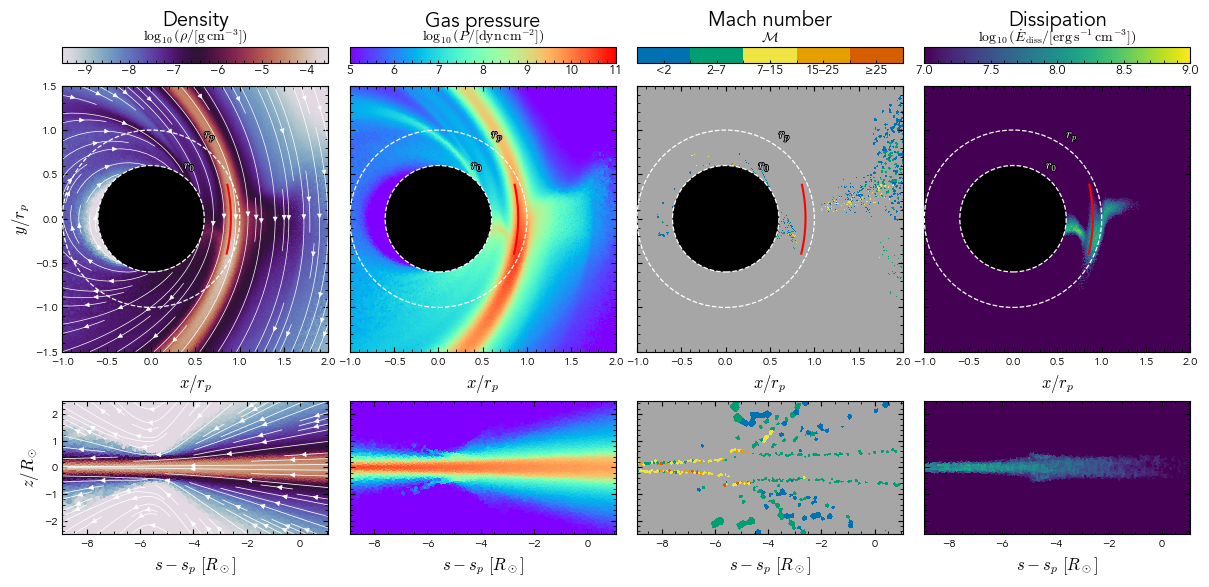

In [3]:
run = "1e4"
snapnum = SNAPSHOTS[run]

with np.load(XY_CACHES[run]) as data:
    time_tfb = float(data["time_tfb"])
    xy_x = np.array(data["x_rp"])
    xy_y = np.array(data["y_rp"])
    xy_density = np.array(data["density"])
    xy_pressure = np.array(data["pressure"])
    xy_dissipation = np.array(data["dissipation"])
    xy_vx = np.array(data["vx_kms"])
    xy_vy = np.array(data["vy_kms"])
with np.load(
    SHOCK_ROOT / "mach-slices" / run / f"mach_P_snap_{snapnum:04d}.npz"
) as data:
    xy_mach = np.array(data["nozzle_xy_mach_P"])
with np.load(ZOOM_CACHES[run]) as data:
    orbit_phi = np.array(data["nozzle_orbit_phi"])
    orbit_z = np.array(data["nozzle_orbit_z_rsun"])
    orbit_x = np.array(data["nozzle_orbit_x_rp"])
    orbit_y = np.array(data["nozzle_orbit_y_rp"])
    orbit_density = np.array(data["nozzle_orbit_density"])
    orbit_pressure = np.array(data["nozzle_orbit_pressure"])
    orbit_mach = np.array(data["nozzle_orbit_mach_P"])
    orbit_dissipation = np.array(data["nozzle_orbit_dissipation"])
    orbit_dphi = np.array(data["nozzle_orbit_dphi_dt"])
    orbit_dz = np.array(data["nozzle_orbit_dz_rsun_dt"])
    orbit_box_scale = float(data["nozzle_orbit_box_scale"])
    orbit_radius_scale = float(data["nozzle_orbit_radius_scale"])
    orbit_phase_deg = float(data["nozzle_orbit_phase_deg"])
with np.load(
    SHOCK_ROOT / "cells" / f"{run}_shock_cells_snap_{snapnum:04d}.npz"
) as data:
    r_p_rsun = float(data["r_p_rsun"])

orbit_s = np.concatenate(
    ([0.0], np.cumsum(np.hypot(np.diff(orbit_x), np.diff(orbit_y))))
) * r_p_rsun
orbit_s -= orbit_s[np.argmin(np.hypot(orbit_x, orbit_y))]
orbit_s -= ORBIT_S_SHIFT_RSUN[run]
orbit_ds = orbit_dphi * np.gradient(orbit_s, orbit_phi)[:, None]
orbit_s_stream = np.linspace(orbit_s[0], orbit_s[-1], orbit_s.size)
orbit_ds_stream = np.stack(
    [
        np.interp(orbit_s_stream, orbit_s, orbit_ds[:, column])
        for column in range(orbit_ds.shape[1])
    ],
    axis=1,
)
orbit_dz_stream = np.stack(
    [
        np.interp(orbit_s_stream, orbit_s, orbit_dz[:, column])
        for column in range(orbit_dz.shape[1])
    ],
    axis=1,
)

if MASK_SMOOTHING_REGION:
    smoothing_mask = np.hypot(xy_x[:, None], xy_y[None, :]) < SMOOTHING_RADIUS_RP
    xy_density = np.where(smoothing_mask, np.nan, xy_density)
    xy_pressure = np.where(smoothing_mask, np.nan, xy_pressure)
    xy_mach = np.where(smoothing_mask, np.nan, xy_mach)
    xy_dissipation = np.where(smoothing_mask, np.nan, xy_dissipation)
    xy_vx = np.where(smoothing_mask, np.nan, xy_vx)
    xy_vy = np.where(smoothing_mask, np.nan, xy_vy)

shared_limits = {
    "density": logged_limits(
        np.concatenate((xy_density.ravel(), orbit_density.ravel())),
        DENSITY_DECADES,
    ),
    "pressure": logged_limits(
        np.concatenate((xy_pressure.ravel(), orbit_pressure.ravel())),
        DENSITY_DECADES,
    ),
    "mach": None,
    "dissipation": logged_limits(
        np.concatenate((xy_dissipation.ravel(), orbit_dissipation.ravel())),
        DISSIPATION_DECADES,
    ),
}
fields = (
    (
        "density",
        "Density",
        r"$\log_{10}(\rho/[\mathrm{g\,cm^{-3}}])$",
        DENSITY_CMAP,
    ),
    (
        "pressure",
        "Gas pressure",
        r"$\log_{10}(P/[\mathrm{dyn\,cm^{-2}}])$",
        PRESSURE_CMAP,
    ),
    ("mach", "Mach number", r"$\mathcal{M}$", MACH_CMAP),
    (
        "dissipation",
        "Dissipation",
        r"$\log_{10}(\dot E_{\rm diss}/[\mathrm{erg\,s^{-1}\,cm^{-3}}])$",
        DISSIPATION_CMAP,
    ),
)
xy_grids = {
    "density": xy_density,
    "pressure": xy_pressure,
    "mach": xy_mach,
    "dissipation": xy_dissipation,
}
orbit_grids = {
    "density": orbit_density,
    "pressure": orbit_pressure,
    "mach": orbit_mach,
    "dissipation": orbit_dissipation,
}

fig, axes = plt.subplots(
    2,
    4,
    figsize=FIGSIZE,
    gridspec_kw={"height_ratios": (2, 1), "wspace": 0.08, "hspace": 0.22},
)
for column, (name, title, label, cmap_name) in enumerate(fields):
    plot_cmap = plt.get_cmap(cmap_name).copy()
    plot_cmap.set_bad(MASK_COLOR)

    xy_grid = xy_grids[name]
    if name == "mach":
        xy_grid = mach_categories(xy_grid, shock_surface=True)
    _, xy_image = scalar_map(
        xy_grid,
        xy_x,
        xy_y,
        ax=axes[0, column],
        cmap=plot_cmap,
        colorbar_label=label,
        log_scale=False,
        aspect_equal=False,
        **(
            {"norm": MACH_NORM}
            if name == "mach"
            else {
                "vmin": shared_limits[name][0],
                "vmax": shared_limits[name][1],
            }
        ),
        shading="auto",
        rasterized=True,
    )
    xy_image.colorbar.remove()
    if name == "mach":
        xy_image.cmap.set_bad(EMPTY_SHOCK_COLOR)
        xy_image.changed()
    compact_colorbar(fig, axes[0, column], xy_image, label)
    axes[0, column].set_title(title, pad=43)
    axes[0, column].set_box_aspect(1.0)
    axes[0, column].set_xlim(XY_WINDOW_RP[:2])
    axes[0, column].set_ylim(XY_WINDOW_RP[2:])
    if MASK_SMOOTHING_REGION:
        axes[0, column].add_patch(
            Circle(
                (0.0, 0.0),
                SMOOTHING_RADIUS_RP,
                facecolor=MASK_COLOR,
                edgecolor="none",
                zorder=8,
            )
        )
    axes[0, column].plot(orbit_x, orbit_y, **SLICE_LINE_STYLE)
    for radius, radius_label in REFERENCE_RADII:
        axes[0, column].add_patch(Circle((0.0, 0.0), radius, **RADIUS_STYLE))
        angle = np.deg2rad(55.0)
        axes[0, column].text(
            radius * np.cos(angle) + 0.025,
            radius * np.sin(angle) + 0.025,
            radius_label,
            color="white",
            fontsize=9,
            ha="left",
            va="bottom",
            path_effects=[
                path_effects.withStroke(linewidth=1.3, foreground="black")
            ],
            zorder=11,
        )

    orbit_grid = orbit_grids[name]
    if name == "mach":
        orbit_grid = mach_categories(orbit_grid, shock_surface=True)
    _, orbit_image = scalar_map(
        orbit_grid,
        orbit_s,
        orbit_z,
        ax=axes[1, column],
        cmap=plot_cmap,
        colorbar_label=label,
        log_scale=False,
        aspect_equal=False,
        **(
            {"norm": MACH_NORM}
            if name == "mach"
            else {
                "vmin": shared_limits[name][0],
                "vmax": shared_limits[name][1],
            }
        ),
        shading="auto",
        rasterized=True,
    )
    orbit_image.colorbar.remove()
    if name == "mach":
        orbit_image.cmap.set_bad(EMPTY_SHOCK_COLOR)
        orbit_image.changed()
    axes[1, column].set_box_aspect(0.5)
    axes[1, column].set_xlim(float(orbit_s[0]), float(orbit_s[-1]))
    axes[1, column].set_ylim(float(orbit_z[0]), float(orbit_z[-1]))

axes[0, 0].streamplot(xy_x, xy_y, xy_vx.T, xy_vy.T, **XY_STREAMLINES)
axes[1, 0].streamplot(
    orbit_s_stream,
    orbit_z,
    orbit_ds_stream.T,
    orbit_dz_stream.T,
    **ORBIT_STREAMLINES,
)
for ax in axes[0]:
    ax.set_xlabel(r"$x/r_p$")
for ax in axes[1]:
    ax.set_xlabel(r"$s-s_p\ [R_\odot]$")
axes[0, 0].set_ylabel(r"$y/r_p$", labelpad=2)
axes[1, 0].set_ylabel(r"$z/R_\odot$", labelpad=2)
for ax in axes[:, 1:].flat:
    ax.tick_params(labelleft=False)
for ax in axes.flat:
    ax.tick_params(labelsize=8)

fig.subplots_adjust(left=0.055, right=0.995, bottom=0.08, top=0.86)
output = OUTPUT_ROOT / f"nozzle_shocks_{run}_snap_{snapnum:04d}.png"
fig.savefig(output, dpi=DPI, facecolor="white")
print(
    f"{run} M_sun | snap {snapnum} | t/t_fb={time_tfb:.4f} | "
    f"orbit box scale={orbit_box_scale:g}, radius scale={orbit_radius_scale:g}, "
    f"phase offset={orbit_phase_deg:+g} deg | nonzero Mach pixels: "
    f"xy={np.count_nonzero(np.nan_to_num(xy_mach)):,}, "
    f"orbit={np.count_nonzero(orbit_mach):,} | {output}"
)
display(fig)
plt.close(fig)


1e5 M_sun | snap 161 | t/t_fb=0.6058 | orbit box scale=0.6, radius scale=1, phase offset=-13 deg | nonzero Mach pixels: xy=62,761, orbit=123,509 | /home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/analysis/zoom-shocks/presentation/nozzle/nozzle_shocks_1e5_snap_0161.png


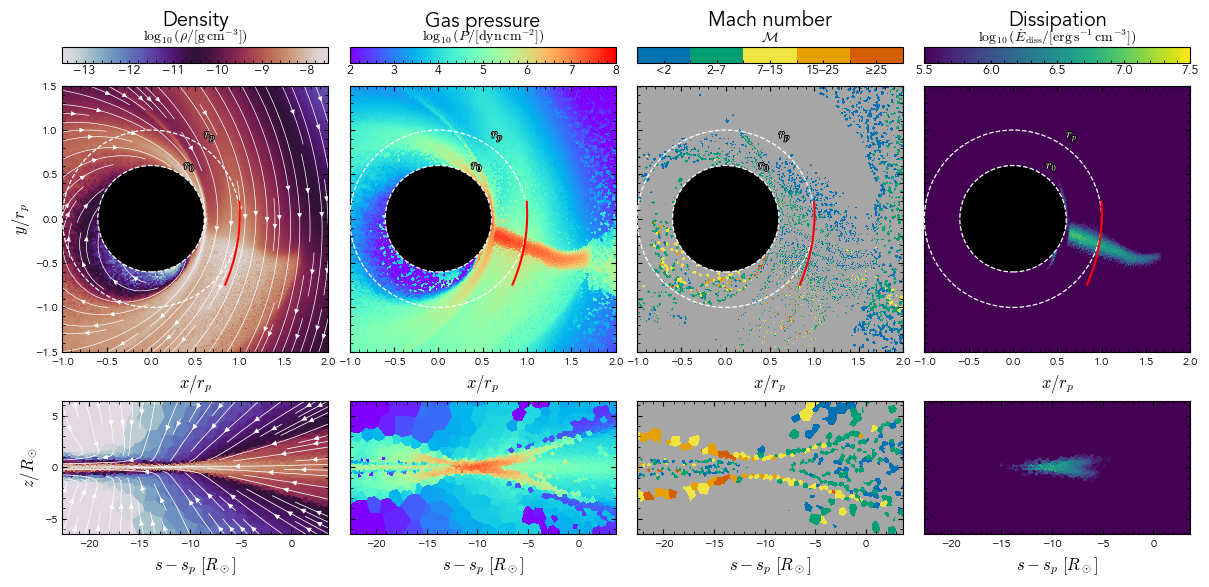

In [4]:
run = "1e5"
snapnum = SNAPSHOTS[run]

with np.load(XY_CACHES[run]) as data:
    time_tfb = float(data["time_tfb"])
    xy_x = np.array(data["x_rp"])
    xy_y = np.array(data["y_rp"])
    xy_density = np.array(data["density"])
    xy_pressure = np.array(data["pressure"])
    xy_dissipation = np.array(data["dissipation"])
    xy_vx = np.array(data["vx_kms"])
    xy_vy = np.array(data["vy_kms"])
with np.load(
    SHOCK_ROOT / "mach-slices" / run / f"mach_P_snap_{snapnum:04d}.npz"
) as data:
    xy_mach = np.array(data["nozzle_xy_mach_P"])
with np.load(ZOOM_CACHES[run]) as data:
    orbit_phi = np.array(data["nozzle_orbit_phi"])
    orbit_z = np.array(data["nozzle_orbit_z_rsun"])
    orbit_x = np.array(data["nozzle_orbit_x_rp"])
    orbit_y = np.array(data["nozzle_orbit_y_rp"])
    orbit_density = np.array(data["nozzle_orbit_density"])
    orbit_pressure = np.array(data["nozzle_orbit_pressure"])
    orbit_mach = np.array(data["nozzle_orbit_mach_P"])
    orbit_dissipation = np.array(data["nozzle_orbit_dissipation"])
    orbit_dphi = np.array(data["nozzle_orbit_dphi_dt"])
    orbit_dz = np.array(data["nozzle_orbit_dz_rsun_dt"])
    orbit_box_scale = float(data["nozzle_orbit_box_scale"])
    orbit_radius_scale = float(data["nozzle_orbit_radius_scale"])
    orbit_phase_deg = float(data["nozzle_orbit_phase_deg"])
with np.load(
    SHOCK_ROOT / "cells" / f"{run}_shock_cells_snap_{snapnum:04d}.npz"
) as data:
    r_p_rsun = float(data["r_p_rsun"])

orbit_s = np.concatenate(
    ([0.0], np.cumsum(np.hypot(np.diff(orbit_x), np.diff(orbit_y))))
) * r_p_rsun
orbit_s -= orbit_s[np.argmin(np.hypot(orbit_x, orbit_y))]
orbit_s -= ORBIT_S_SHIFT_RSUN[run]
orbit_ds = orbit_dphi * np.gradient(orbit_s, orbit_phi)[:, None]
orbit_s_stream = np.linspace(orbit_s[0], orbit_s[-1], orbit_s.size)
orbit_ds_stream = np.stack(
    [
        np.interp(orbit_s_stream, orbit_s, orbit_ds[:, column])
        for column in range(orbit_ds.shape[1])
    ],
    axis=1,
)
orbit_dz_stream = np.stack(
    [
        np.interp(orbit_s_stream, orbit_s, orbit_dz[:, column])
        for column in range(orbit_dz.shape[1])
    ],
    axis=1,
)

if MASK_SMOOTHING_REGION:
    smoothing_mask = np.hypot(xy_x[:, None], xy_y[None, :]) < SMOOTHING_RADIUS_RP
    xy_density = np.where(smoothing_mask, np.nan, xy_density)
    xy_pressure = np.where(smoothing_mask, np.nan, xy_pressure)
    xy_mach = np.where(smoothing_mask, np.nan, xy_mach)
    xy_dissipation = np.where(smoothing_mask, np.nan, xy_dissipation)
    xy_vx = np.where(smoothing_mask, np.nan, xy_vx)
    xy_vy = np.where(smoothing_mask, np.nan, xy_vy)

shared_limits = {
    "density": logged_limits(
        np.concatenate((xy_density.ravel(), orbit_density.ravel())),
        DENSITY_DECADES,
    ),
    "pressure": logged_limits(
        np.concatenate((xy_pressure.ravel(), orbit_pressure.ravel())),
        DENSITY_DECADES,
    ),
    "mach": None,
    "dissipation": logged_limits(
        np.concatenate((xy_dissipation.ravel(), orbit_dissipation.ravel())),
        DISSIPATION_DECADES,
    ),
}
fields = (
    (
        "density",
        "Density",
        r"$\log_{10}(\rho/[\mathrm{g\,cm^{-3}}])$",
        DENSITY_CMAP,
    ),
    (
        "pressure",
        "Gas pressure",
        r"$\log_{10}(P/[\mathrm{dyn\,cm^{-2}}])$",
        PRESSURE_CMAP,
    ),
    ("mach", "Mach number", r"$\mathcal{M}$", MACH_CMAP),
    (
        "dissipation",
        "Dissipation",
        r"$\log_{10}(\dot E_{\rm diss}/[\mathrm{erg\,s^{-1}\,cm^{-3}}])$",
        DISSIPATION_CMAP,
    ),
)
xy_grids = {
    "density": xy_density,
    "pressure": xy_pressure,
    "mach": xy_mach,
    "dissipation": xy_dissipation,
}
orbit_grids = {
    "density": orbit_density,
    "pressure": orbit_pressure,
    "mach": orbit_mach,
    "dissipation": orbit_dissipation,
}

fig, axes = plt.subplots(
    2,
    4,
    figsize=FIGSIZE,
    gridspec_kw={"height_ratios": (2, 1), "wspace": 0.08, "hspace": 0.22},
)
for column, (name, title, label, cmap_name) in enumerate(fields):
    plot_cmap = plt.get_cmap(cmap_name).copy()
    plot_cmap.set_bad(MASK_COLOR)

    xy_grid = xy_grids[name]
    if name == "mach":
        xy_grid = mach_categories(xy_grid, shock_surface=True)
    _, xy_image = scalar_map(
        xy_grid,
        xy_x,
        xy_y,
        ax=axes[0, column],
        cmap=plot_cmap,
        colorbar_label=label,
        log_scale=False,
        aspect_equal=False,
        **(
            {"norm": MACH_NORM}
            if name == "mach"
            else {
                "vmin": shared_limits[name][0],
                "vmax": shared_limits[name][1],
            }
        ),
        shading="auto",
        rasterized=True,
    )
    xy_image.colorbar.remove()
    if name == "mach":
        xy_image.cmap.set_bad(EMPTY_SHOCK_COLOR)
        xy_image.changed()
    compact_colorbar(fig, axes[0, column], xy_image, label)
    axes[0, column].set_title(title, pad=43)
    axes[0, column].set_box_aspect(1.0)
    axes[0, column].set_xlim(XY_WINDOW_RP[:2])
    axes[0, column].set_ylim(XY_WINDOW_RP[2:])
    if MASK_SMOOTHING_REGION:
        axes[0, column].add_patch(
            Circle(
                (0.0, 0.0),
                SMOOTHING_RADIUS_RP,
                facecolor=MASK_COLOR,
                edgecolor="none",
                zorder=8,
            )
        )
    axes[0, column].plot(orbit_x, orbit_y, **SLICE_LINE_STYLE)
    for radius, radius_label in REFERENCE_RADII:
        axes[0, column].add_patch(Circle((0.0, 0.0), radius, **RADIUS_STYLE))
        angle = np.deg2rad(55.0)
        axes[0, column].text(
            radius * np.cos(angle) + 0.025,
            radius * np.sin(angle) + 0.025,
            radius_label,
            color="white",
            fontsize=9,
            ha="left",
            va="bottom",
            path_effects=[
                path_effects.withStroke(linewidth=1.3, foreground="black")
            ],
            zorder=11,
        )

    orbit_grid = orbit_grids[name]
    if name == "mach":
        orbit_grid = mach_categories(orbit_grid, shock_surface=True)
    _, orbit_image = scalar_map(
        orbit_grid,
        orbit_s,
        orbit_z,
        ax=axes[1, column],
        cmap=plot_cmap,
        colorbar_label=label,
        log_scale=False,
        aspect_equal=False,
        **(
            {"norm": MACH_NORM}
            if name == "mach"
            else {
                "vmin": shared_limits[name][0],
                "vmax": shared_limits[name][1],
            }
        ),
        shading="auto",
        rasterized=True,
    )
    orbit_image.colorbar.remove()
    if name == "mach":
        orbit_image.cmap.set_bad(EMPTY_SHOCK_COLOR)
        orbit_image.changed()
    axes[1, column].set_box_aspect(0.5)
    axes[1, column].set_xlim(float(orbit_s[0]), float(orbit_s[-1]))
    axes[1, column].set_ylim(float(orbit_z[0]), float(orbit_z[-1]))

axes[0, 0].streamplot(xy_x, xy_y, xy_vx.T, xy_vy.T, **XY_STREAMLINES)
axes[1, 0].streamplot(
    orbit_s_stream,
    orbit_z,
    orbit_ds_stream.T,
    orbit_dz_stream.T,
    **ORBIT_STREAMLINES,
)
for ax in axes[0]:
    ax.set_xlabel(r"$x/r_p$")
for ax in axes[1]:
    ax.set_xlabel(r"$s-s_p\ [R_\odot]$")
axes[0, 0].set_ylabel(r"$y/r_p$", labelpad=2)
axes[1, 0].set_ylabel(r"$z/R_\odot$", labelpad=2)
for ax in axes[:, 1:].flat:
    ax.tick_params(labelleft=False)
for ax in axes.flat:
    ax.tick_params(labelsize=8)

fig.subplots_adjust(left=0.055, right=0.995, bottom=0.08, top=0.86)
output = OUTPUT_ROOT / f"nozzle_shocks_{run}_snap_{snapnum:04d}.png"
fig.savefig(output, dpi=DPI, facecolor="white")
print(
    f"{run} M_sun | snap {snapnum} | t/t_fb={time_tfb:.4f} | "
    f"orbit box scale={orbit_box_scale:g}, radius scale={orbit_radius_scale:g}, "
    f"phase offset={orbit_phase_deg:+g} deg | nonzero Mach pixels: "
    f"xy={np.count_nonzero(np.nan_to_num(xy_mach)):,}, "
    f"orbit={np.count_nonzero(orbit_mach):,} | {output}"
)
display(fig)
plt.close(fig)


1e6 M_sun | snap 850 | t/t_fb=1.0015 | orbit box scale=0.6, radius scale=1, phase offset=-13 deg | nonzero Mach pixels: xy=45,474, orbit=52,816 | /home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/analysis/zoom-shocks/presentation/nozzle/nozzle_shocks_1e6_snap_0850.png


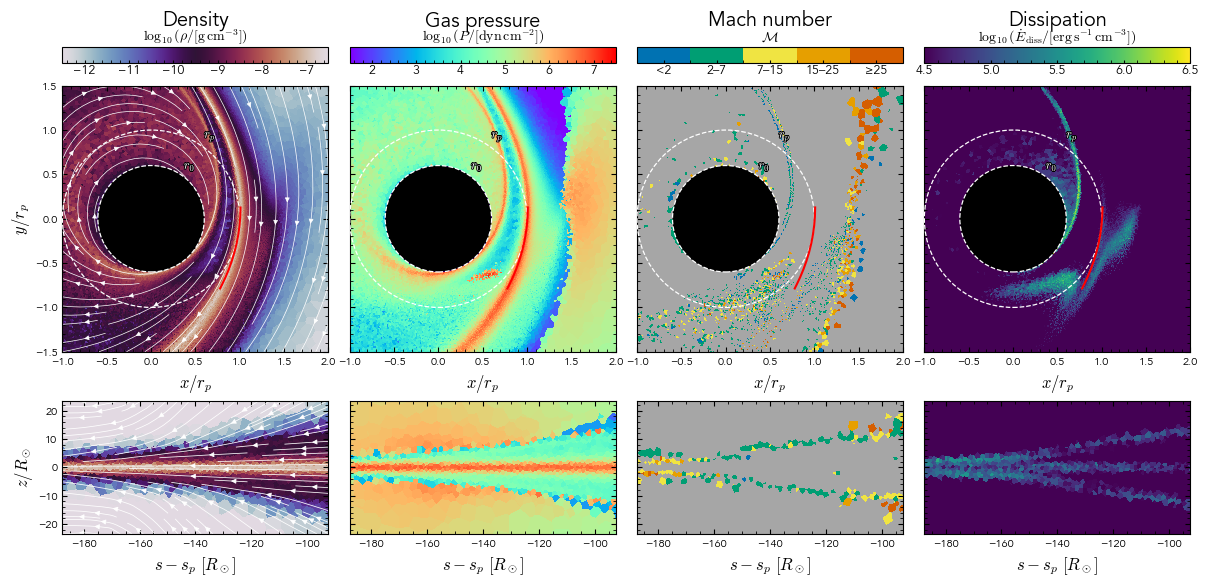

In [5]:
run = "1e6"
snapnum = SNAPSHOTS[run]

with np.load(XY_CACHES[run]) as data:
    time_tfb = float(data["time_tfb"])
    xy_x = np.array(data["x_rp"])
    xy_y = np.array(data["y_rp"])
    xy_density = np.array(data["density"])
    xy_pressure = np.array(data["pressure"])
    xy_dissipation = np.array(data["dissipation"])
    xy_vx = np.array(data["vx_kms"])
    xy_vy = np.array(data["vy_kms"])
with np.load(
    SHOCK_ROOT / "mach-slices" / run / f"mach_P_snap_{snapnum:04d}.npz"
) as data:
    xy_mach = np.array(data["nozzle_xy_mach_P"])
with np.load(ZOOM_CACHES[run]) as data:
    orbit_phi = np.array(data["nozzle_orbit_phi"])
    orbit_z = np.array(data["nozzle_orbit_z_rsun"])
    orbit_x = np.array(data["nozzle_orbit_x_rp"])
    orbit_y = np.array(data["nozzle_orbit_y_rp"])
    orbit_density = np.array(data["nozzle_orbit_density"])
    orbit_pressure = np.array(data["nozzle_orbit_pressure"])
    orbit_mach = np.array(data["nozzle_orbit_mach_P"])
    orbit_dissipation = np.array(data["nozzle_orbit_dissipation"])
    orbit_dphi = np.array(data["nozzle_orbit_dphi_dt"])
    orbit_dz = np.array(data["nozzle_orbit_dz_rsun_dt"])
    orbit_box_scale = float(data["nozzle_orbit_box_scale"])
    orbit_radius_scale = float(data["nozzle_orbit_radius_scale"])
    orbit_phase_deg = float(data["nozzle_orbit_phase_deg"])
with np.load(
    SHOCK_ROOT / "cells" / f"{run}_shock_cells_snap_{snapnum:04d}.npz"
) as data:
    r_p_rsun = float(data["r_p_rsun"])

orbit_s = np.concatenate(
    ([0.0], np.cumsum(np.hypot(np.diff(orbit_x), np.diff(orbit_y))))
) * r_p_rsun
orbit_s -= orbit_s[np.argmin(np.hypot(orbit_x, orbit_y))]
orbit_s -= ORBIT_S_SHIFT_RSUN[run]
orbit_ds = orbit_dphi * np.gradient(orbit_s, orbit_phi)[:, None]
orbit_s_stream = np.linspace(orbit_s[0], orbit_s[-1], orbit_s.size)
orbit_ds_stream = np.stack(
    [
        np.interp(orbit_s_stream, orbit_s, orbit_ds[:, column])
        for column in range(orbit_ds.shape[1])
    ],
    axis=1,
)
orbit_dz_stream = np.stack(
    [
        np.interp(orbit_s_stream, orbit_s, orbit_dz[:, column])
        for column in range(orbit_dz.shape[1])
    ],
    axis=1,
)

if MASK_SMOOTHING_REGION:
    smoothing_mask = np.hypot(xy_x[:, None], xy_y[None, :]) < SMOOTHING_RADIUS_RP
    xy_density = np.where(smoothing_mask, np.nan, xy_density)
    xy_pressure = np.where(smoothing_mask, np.nan, xy_pressure)
    xy_mach = np.where(smoothing_mask, np.nan, xy_mach)
    xy_dissipation = np.where(smoothing_mask, np.nan, xy_dissipation)
    xy_vx = np.where(smoothing_mask, np.nan, xy_vx)
    xy_vy = np.where(smoothing_mask, np.nan, xy_vy)

shared_limits = {
    "density": logged_limits(
        np.concatenate((xy_density.ravel(), orbit_density.ravel())),
        DENSITY_DECADES,
    ),
    "pressure": logged_limits(
        np.concatenate((xy_pressure.ravel(), orbit_pressure.ravel())),
        DENSITY_DECADES,
    ),
    "mach": None,
    "dissipation": logged_limits(
        np.concatenate((xy_dissipation.ravel(), orbit_dissipation.ravel())),
        DISSIPATION_DECADES,
    ),
}
fields = (
    (
        "density",
        "Density",
        r"$\log_{10}(\rho/[\mathrm{g\,cm^{-3}}])$",
        DENSITY_CMAP,
    ),
    (
        "pressure",
        "Gas pressure",
        r"$\log_{10}(P/[\mathrm{dyn\,cm^{-2}}])$",
        PRESSURE_CMAP,
    ),
    ("mach", "Mach number", r"$\mathcal{M}$", MACH_CMAP),
    (
        "dissipation",
        "Dissipation",
        r"$\log_{10}(\dot E_{\rm diss}/[\mathrm{erg\,s^{-1}\,cm^{-3}}])$",
        DISSIPATION_CMAP,
    ),
)
xy_grids = {
    "density": xy_density,
    "pressure": xy_pressure,
    "mach": xy_mach,
    "dissipation": xy_dissipation,
}
orbit_grids = {
    "density": orbit_density,
    "pressure": orbit_pressure,
    "mach": orbit_mach,
    "dissipation": orbit_dissipation,
}

fig, axes = plt.subplots(
    2,
    4,
    figsize=FIGSIZE,
    gridspec_kw={"height_ratios": (2, 1), "wspace": 0.08, "hspace": 0.22},
)
for column, (name, title, label, cmap_name) in enumerate(fields):
    plot_cmap = plt.get_cmap(cmap_name).copy()
    plot_cmap.set_bad(MASK_COLOR)

    xy_grid = xy_grids[name]
    if name == "mach":
        xy_grid = mach_categories(xy_grid, shock_surface=True)
    _, xy_image = scalar_map(
        xy_grid,
        xy_x,
        xy_y,
        ax=axes[0, column],
        cmap=plot_cmap,
        colorbar_label=label,
        log_scale=False,
        aspect_equal=False,
        **(
            {"norm": MACH_NORM}
            if name == "mach"
            else {
                "vmin": shared_limits[name][0],
                "vmax": shared_limits[name][1],
            }
        ),
        shading="auto",
        rasterized=True,
    )
    xy_image.colorbar.remove()
    if name == "mach":
        xy_image.cmap.set_bad(EMPTY_SHOCK_COLOR)
        xy_image.changed()
    compact_colorbar(fig, axes[0, column], xy_image, label)
    axes[0, column].set_title(title, pad=43)
    axes[0, column].set_box_aspect(1.0)
    axes[0, column].set_xlim(XY_WINDOW_RP[:2])
    axes[0, column].set_ylim(XY_WINDOW_RP[2:])
    if MASK_SMOOTHING_REGION:
        axes[0, column].add_patch(
            Circle(
                (0.0, 0.0),
                SMOOTHING_RADIUS_RP,
                facecolor=MASK_COLOR,
                edgecolor="none",
                zorder=8,
            )
        )
    axes[0, column].plot(orbit_x, orbit_y, **SLICE_LINE_STYLE)
    for radius, radius_label in REFERENCE_RADII:
        axes[0, column].add_patch(Circle((0.0, 0.0), radius, **RADIUS_STYLE))
        angle = np.deg2rad(55.0)
        axes[0, column].text(
            radius * np.cos(angle) + 0.025,
            radius * np.sin(angle) + 0.025,
            radius_label,
            color="white",
            fontsize=9,
            ha="left",
            va="bottom",
            path_effects=[
                path_effects.withStroke(linewidth=1.3, foreground="black")
            ],
            zorder=11,
        )

    orbit_grid = orbit_grids[name]
    if name == "mach":
        orbit_grid = mach_categories(orbit_grid, shock_surface=True)
    _, orbit_image = scalar_map(
        orbit_grid,
        orbit_s,
        orbit_z,
        ax=axes[1, column],
        cmap=plot_cmap,
        colorbar_label=label,
        log_scale=False,
        aspect_equal=False,
        **(
            {"norm": MACH_NORM}
            if name == "mach"
            else {
                "vmin": shared_limits[name][0],
                "vmax": shared_limits[name][1],
            }
        ),
        shading="auto",
        rasterized=True,
    )
    orbit_image.colorbar.remove()
    if name == "mach":
        orbit_image.cmap.set_bad(EMPTY_SHOCK_COLOR)
        orbit_image.changed()
    axes[1, column].set_box_aspect(0.5)
    axes[1, column].set_xlim(float(orbit_s[0]), float(orbit_s[-1]))
    axes[1, column].set_ylim(float(orbit_z[0]), float(orbit_z[-1]))

axes[0, 0].streamplot(xy_x, xy_y, xy_vx.T, xy_vy.T, **XY_STREAMLINES)
axes[1, 0].streamplot(
    orbit_s_stream,
    orbit_z,
    orbit_ds_stream.T,
    orbit_dz_stream.T,
    **ORBIT_STREAMLINES,
)
for ax in axes[0]:
    ax.set_xlabel(r"$x/r_p$")
for ax in axes[1]:
    ax.set_xlabel(r"$s-s_p\ [R_\odot]$")
axes[0, 0].set_ylabel(r"$y/r_p$", labelpad=2)
axes[1, 0].set_ylabel(r"$z/R_\odot$", labelpad=2)
for ax in axes[:, 1:].flat:
    ax.tick_params(labelleft=False)
for ax in axes.flat:
    ax.tick_params(labelsize=8)

fig.subplots_adjust(left=0.055, right=0.995, bottom=0.08, top=0.86)
output = OUTPUT_ROOT / f"nozzle_shocks_{run}_snap_{snapnum:04d}.png"
fig.savefig(output, dpi=DPI, facecolor="white")
print(
    f"{run} M_sun | snap {snapnum} | t/t_fb={time_tfb:.4f} | "
    f"orbit box scale={orbit_box_scale:g}, radius scale={orbit_radius_scale:g}, "
    f"phase offset={orbit_phase_deg:+g} deg | nonzero Mach pixels: "
    f"xy={np.count_nonzero(np.nan_to_num(xy_mach)):,}, "
    f"orbit={np.count_nonzero(orbit_mach):,} | {output}"
)
display(fig)
plt.close(fig)


1e4 M_sun | snap 77 | t/t_fb=0.9990 | orbit box scale=0.5, radius scale=0.9, phase offset=+0 deg | /home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/analysis/zoom-shocks/presentation/nozzle/nozzle_energies_mach_1e4_snap_0077.png


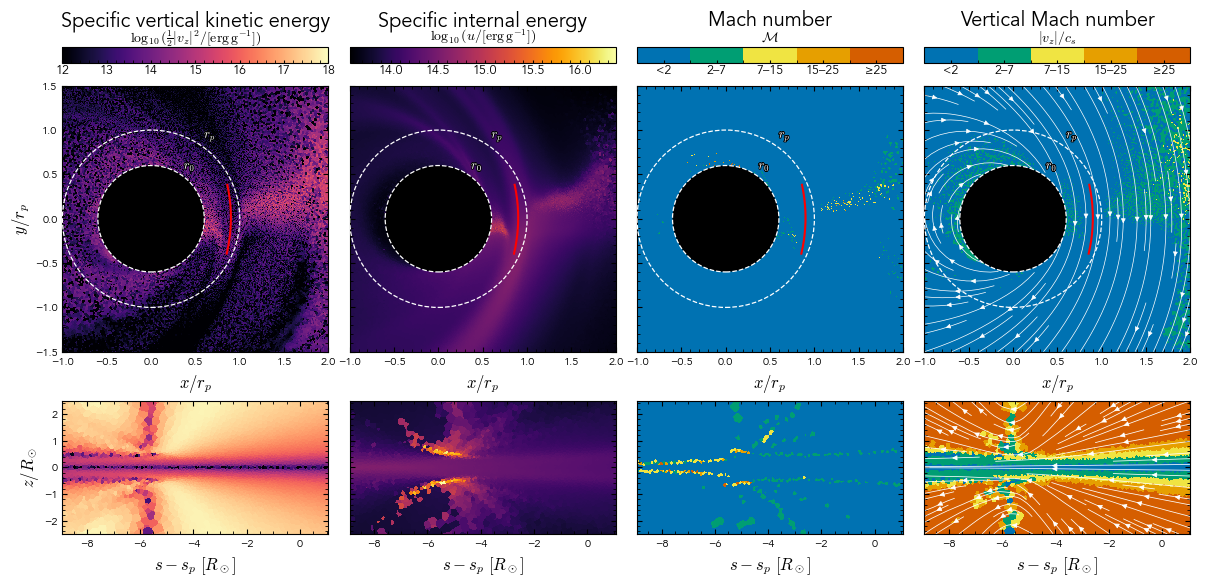

In [6]:
run = "1e4"
snapnum = SNAPSHOTS[run]

with np.load(
    SHOCK_ROOT / "mach-slices" / run / f"mach_P_snap_{snapnum:04d}.npz"
) as data:
    xy_mach = np.array(data["nozzle_xy_mach_P"])
with np.load(ZOOM_CACHES[run]) as data:
    time_tfb = float(data["time_tfb"])
    xy_x = np.array(data["nozzle_xy_x_rp"])
    xy_y = np.array(data["nozzle_xy_y_rp"])
    xy_vertical_kinetic = np.array(data["nozzle_xy_specific_vertical_kinetic"])
    xy_internal_energy = np.array(data["nozzle_xy_specific_internal_energy"])
    xy_vertical_mach = np.array(data["nozzle_xy_abs_vz_over_cs"])
    xy_vx = np.array(data["nozzle_xy_vx_kms"])
    xy_vy = np.array(data["nozzle_xy_vy_kms"])

    orbit_phi = np.array(data["nozzle_orbit_phi"])
    orbit_z = np.array(data["nozzle_orbit_z_rsun"])
    orbit_x = np.array(data["nozzle_orbit_x_rp"])
    orbit_y = np.array(data["nozzle_orbit_y_rp"])
    orbit_vertical_kinetic = np.array(
        data["nozzle_orbit_specific_vertical_kinetic"]
    )
    orbit_internal_energy = np.array(
        data["nozzle_orbit_specific_internal_energy"]
    )
    orbit_mach = np.array(data["nozzle_orbit_mach_P"])
    orbit_vertical_mach = np.array(data["nozzle_orbit_abs_vz_over_cs"])
    orbit_dphi = np.array(data["nozzle_orbit_dphi_dt"])
    orbit_dz = np.array(data["nozzle_orbit_dz_rsun_dt"])
    orbit_box_scale = float(data["nozzle_orbit_box_scale"])
    orbit_radius_scale = float(data["nozzle_orbit_radius_scale"])
    orbit_phase_deg = float(data["nozzle_orbit_phase_deg"])
with np.load(
    SHOCK_ROOT / "cells" / f"{run}_shock_cells_snap_{snapnum:04d}.npz"
) as data:
    r_p_rsun = float(data["r_p_rsun"])

orbit_s = np.concatenate(
    ([0.0], np.cumsum(np.hypot(np.diff(orbit_x), np.diff(orbit_y))))
) * r_p_rsun
orbit_s -= orbit_s[np.argmin(np.hypot(orbit_x, orbit_y))]
orbit_s -= ORBIT_S_SHIFT_RSUN[run]
orbit_ds = orbit_dphi * np.gradient(orbit_s, orbit_phi)[:, None]
orbit_s_stream = np.linspace(orbit_s[0], orbit_s[-1], orbit_s.size)
orbit_ds_stream = np.stack(
    [
        np.interp(orbit_s_stream, orbit_s, orbit_ds[:, column])
        for column in range(orbit_ds.shape[1])
    ],
    axis=1,
)
orbit_dz_stream = np.stack(
    [
        np.interp(orbit_s_stream, orbit_s, orbit_dz[:, column])
        for column in range(orbit_dz.shape[1])
    ],
    axis=1,
)

if MASK_SMOOTHING_REGION:
    smoothing_mask = np.hypot(xy_x[:, None], xy_y[None, :]) < SMOOTHING_RADIUS_RP
    xy_vertical_kinetic = np.where(smoothing_mask, np.nan, xy_vertical_kinetic)
    xy_internal_energy = np.where(smoothing_mask, np.nan, xy_internal_energy)
    xy_mach = np.where(smoothing_mask, np.nan, xy_mach)
    xy_vertical_mach = np.where(smoothing_mask, np.nan, xy_vertical_mach)
    xy_vx = np.where(smoothing_mask, np.nan, xy_vx)
    xy_vy = np.where(smoothing_mask, np.nan, xy_vy)

shared_limits = {
    "vertical_kinetic": logged_limits(
        np.concatenate((xy_vertical_kinetic.ravel(), orbit_vertical_kinetic.ravel())),
        ENERGY_DECADES,
    ),
    "internal_energy": logged_limits(
        np.concatenate((xy_internal_energy.ravel(), orbit_internal_energy.ravel())),
        ENERGY_DECADES,
    ),
    "mach": None,
    "vertical_mach": None,
}
fields = (
    (
        "vertical_kinetic",
        "Specific vertical kinetic energy",
        r"$\log_{10}(\frac{1}{2}|v_z|^2/[\mathrm{erg\,g^{-1}}])$",
        "magma",
    ),
    (
        "internal_energy",
        "Specific internal energy",
        r"$\log_{10}(u/[\mathrm{erg\,g^{-1}}])$",
        "inferno",
    ),
    ("mach", "Mach number", r"$\mathcal{M}$", MACH_CMAP),
    ("vertical_mach", "Vertical Mach number", r"$|v_z|/c_s$", MACH_CMAP),
)
xy_grids = {
    "vertical_kinetic": xy_vertical_kinetic,
    "internal_energy": xy_internal_energy,
    "mach": xy_mach,
    "vertical_mach": xy_vertical_mach,
}
orbit_grids = {
    "vertical_kinetic": orbit_vertical_kinetic,
    "internal_energy": orbit_internal_energy,
    "mach": orbit_mach,
    "vertical_mach": orbit_vertical_mach,
}

fig, axes = plt.subplots(
    2,
    4,
    figsize=FIGSIZE,
    gridspec_kw={"height_ratios": (2, 1), "wspace": 0.08, "hspace": 0.22},
)
for column, (name, title, label, cmap_name) in enumerate(fields):
    categorical = name in {"mach", "vertical_mach"}
    plot_cmap = plt.get_cmap(cmap_name).copy()
    plot_cmap.set_bad(EMPTY_SHOCK_COLOR if name == "mach" else MASK_COLOR)

    xy_grid = xy_grids[name]
    if categorical:
        xy_grid = mach_categories(xy_grid, shock_surface=name == "mach")
    _, xy_image = scalar_map(
        xy_grid,
        xy_x,
        xy_y,
        ax=axes[0, column],
        cmap=plot_cmap,
        colorbar_label=label,
        log_scale=False,
        aspect_equal=False,
        **(
            {"norm": MACH_NORM}
            if categorical
            else {
                "vmin": shared_limits[name][0],
                "vmax": shared_limits[name][1],
            }
        ),
        shading="auto",
        rasterized=True,
    )
    xy_image.colorbar.remove()
    compact_colorbar(fig, axes[0, column], xy_image, label)
    axes[0, column].set_title(title, pad=43)
    axes[0, column].set_box_aspect(1.0)
    axes[0, column].set_xlim(XY_WINDOW_RP[:2])
    axes[0, column].set_ylim(XY_WINDOW_RP[2:])
    if MASK_SMOOTHING_REGION:
        axes[0, column].add_patch(
            Circle(
                (0.0, 0.0),
                SMOOTHING_RADIUS_RP,
                facecolor=MASK_COLOR,
                edgecolor="none",
                zorder=8,
            )
        )
    axes[0, column].plot(orbit_x, orbit_y, **SLICE_LINE_STYLE)
    for radius, radius_label in REFERENCE_RADII:
        axes[0, column].add_patch(Circle((0.0, 0.0), radius, **RADIUS_STYLE))
        angle = np.deg2rad(55.0)
        axes[0, column].text(
            radius * np.cos(angle) + 0.025,
            radius * np.sin(angle) + 0.025,
            radius_label,
            color="white",
            fontsize=9,
            ha="left",
            va="bottom",
            path_effects=[
                path_effects.withStroke(linewidth=1.3, foreground="black")
            ],
            zorder=11,
        )

    orbit_grid = orbit_grids[name]
    if categorical:
        orbit_grid = mach_categories(orbit_grid, shock_surface=name == "mach")
    _, orbit_image = scalar_map(
        orbit_grid,
        orbit_s,
        orbit_z,
        ax=axes[1, column],
        cmap=plot_cmap,
        colorbar_label=label,
        log_scale=False,
        aspect_equal=False,
        **(
            {"norm": MACH_NORM}
            if categorical
            else {
                "vmin": shared_limits[name][0],
                "vmax": shared_limits[name][1],
            }
        ),
        shading="auto",
        rasterized=True,
    )
    orbit_image.colorbar.remove()
    axes[1, column].set_box_aspect(0.5)
    axes[1, column].set_xlim(float(orbit_s[0]), float(orbit_s[-1]))
    axes[1, column].set_ylim(float(orbit_z[0]), float(orbit_z[-1]))

axes[0, 3].streamplot(xy_x, xy_y, xy_vx.T, xy_vy.T, **XY_STREAMLINES)
axes[1, 3].streamplot(
    orbit_s_stream,
    orbit_z,
    orbit_ds_stream.T,
    orbit_dz_stream.T,
    **ORBIT_STREAMLINES,
)
for ax in axes[0]:
    ax.set_xlabel(r"$x/r_p$")
for ax in axes[1]:
    ax.set_xlabel(r"$s-s_p\ [R_\odot]$")
axes[0, 0].set_ylabel(r"$y/r_p$", labelpad=2)
axes[1, 0].set_ylabel(r"$z/R_\odot$", labelpad=2)
for ax in axes[:, 1:].flat:
    ax.tick_params(labelleft=False)
for ax in axes.flat:
    ax.tick_params(labelsize=8)

fig.subplots_adjust(left=0.055, right=0.995, bottom=0.08, top=0.86)
output = OUTPUT_ROOT / f"nozzle_energies_mach_{run}_snap_{snapnum:04d}.png"
fig.savefig(output, dpi=DPI, facecolor="white")
print(
    f"{run} M_sun | snap {snapnum} | t/t_fb={time_tfb:.4f} | "
    f"orbit box scale={orbit_box_scale:g}, radius scale={orbit_radius_scale:g}, "
    f"phase offset={orbit_phase_deg:+g} deg | {output}"
)
display(fig)
plt.close(fig)


1e5 M_sun | snap 161 | t/t_fb=0.6058 | orbit box scale=0.6, radius scale=1, phase offset=-13 deg | /home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/analysis/zoom-shocks/presentation/nozzle/nozzle_energies_mach_1e5_snap_0161.png


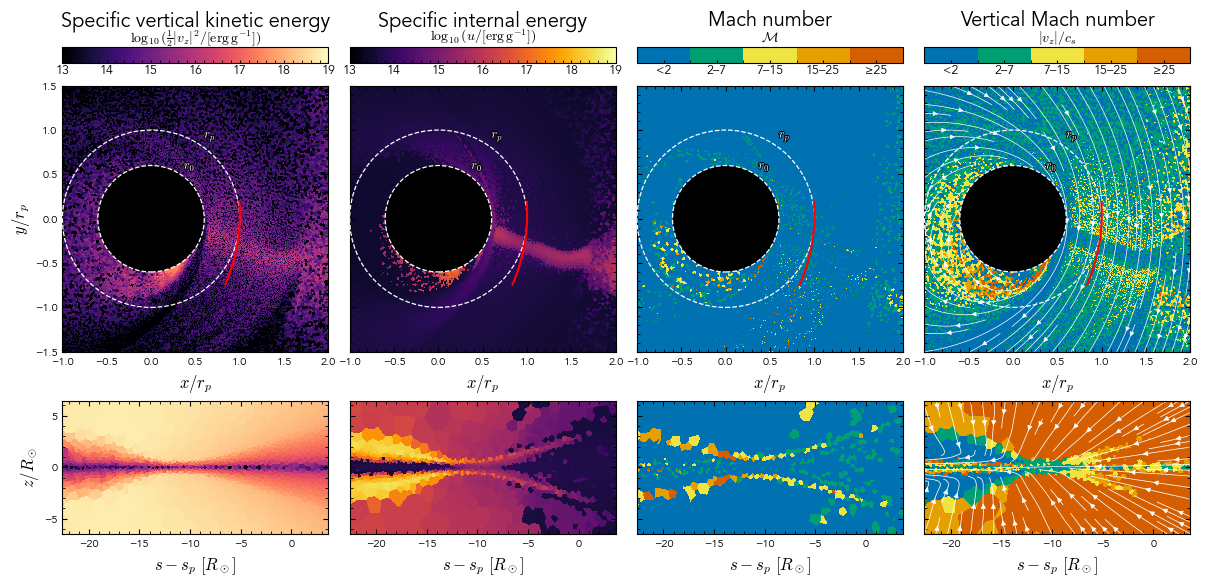

In [7]:
run = "1e5"
snapnum = SNAPSHOTS[run]

with np.load(
    SHOCK_ROOT / "mach-slices" / run / f"mach_P_snap_{snapnum:04d}.npz"
) as data:
    xy_mach = np.array(data["nozzle_xy_mach_P"])
with np.load(ZOOM_CACHES[run]) as data:
    time_tfb = float(data["time_tfb"])
    xy_x = np.array(data["nozzle_xy_x_rp"])
    xy_y = np.array(data["nozzle_xy_y_rp"])
    xy_vertical_kinetic = np.array(data["nozzle_xy_specific_vertical_kinetic"])
    xy_internal_energy = np.array(data["nozzle_xy_specific_internal_energy"])
    xy_vertical_mach = np.array(data["nozzle_xy_abs_vz_over_cs"])
    xy_vx = np.array(data["nozzle_xy_vx_kms"])
    xy_vy = np.array(data["nozzle_xy_vy_kms"])

    orbit_phi = np.array(data["nozzle_orbit_phi"])
    orbit_z = np.array(data["nozzle_orbit_z_rsun"])
    orbit_x = np.array(data["nozzle_orbit_x_rp"])
    orbit_y = np.array(data["nozzle_orbit_y_rp"])
    orbit_vertical_kinetic = np.array(
        data["nozzle_orbit_specific_vertical_kinetic"]
    )
    orbit_internal_energy = np.array(
        data["nozzle_orbit_specific_internal_energy"]
    )
    orbit_mach = np.array(data["nozzle_orbit_mach_P"])
    orbit_vertical_mach = np.array(data["nozzle_orbit_abs_vz_over_cs"])
    orbit_dphi = np.array(data["nozzle_orbit_dphi_dt"])
    orbit_dz = np.array(data["nozzle_orbit_dz_rsun_dt"])
    orbit_box_scale = float(data["nozzle_orbit_box_scale"])
    orbit_radius_scale = float(data["nozzle_orbit_radius_scale"])
    orbit_phase_deg = float(data["nozzle_orbit_phase_deg"])
with np.load(
    SHOCK_ROOT / "cells" / f"{run}_shock_cells_snap_{snapnum:04d}.npz"
) as data:
    r_p_rsun = float(data["r_p_rsun"])

orbit_s = np.concatenate(
    ([0.0], np.cumsum(np.hypot(np.diff(orbit_x), np.diff(orbit_y))))
) * r_p_rsun
orbit_s -= orbit_s[np.argmin(np.hypot(orbit_x, orbit_y))]
orbit_s -= ORBIT_S_SHIFT_RSUN[run]
orbit_ds = orbit_dphi * np.gradient(orbit_s, orbit_phi)[:, None]
orbit_s_stream = np.linspace(orbit_s[0], orbit_s[-1], orbit_s.size)
orbit_ds_stream = np.stack(
    [
        np.interp(orbit_s_stream, orbit_s, orbit_ds[:, column])
        for column in range(orbit_ds.shape[1])
    ],
    axis=1,
)
orbit_dz_stream = np.stack(
    [
        np.interp(orbit_s_stream, orbit_s, orbit_dz[:, column])
        for column in range(orbit_dz.shape[1])
    ],
    axis=1,
)

if MASK_SMOOTHING_REGION:
    smoothing_mask = np.hypot(xy_x[:, None], xy_y[None, :]) < SMOOTHING_RADIUS_RP
    xy_vertical_kinetic = np.where(smoothing_mask, np.nan, xy_vertical_kinetic)
    xy_internal_energy = np.where(smoothing_mask, np.nan, xy_internal_energy)
    xy_mach = np.where(smoothing_mask, np.nan, xy_mach)
    xy_vertical_mach = np.where(smoothing_mask, np.nan, xy_vertical_mach)
    xy_vx = np.where(smoothing_mask, np.nan, xy_vx)
    xy_vy = np.where(smoothing_mask, np.nan, xy_vy)

shared_limits = {
    "vertical_kinetic": logged_limits(
        np.concatenate((xy_vertical_kinetic.ravel(), orbit_vertical_kinetic.ravel())),
        ENERGY_DECADES,
    ),
    "internal_energy": logged_limits(
        np.concatenate((xy_internal_energy.ravel(), orbit_internal_energy.ravel())),
        ENERGY_DECADES,
    ),
    "mach": None,
    "vertical_mach": None,
}
fields = (
    (
        "vertical_kinetic",
        "Specific vertical kinetic energy",
        r"$\log_{10}(\frac{1}{2}|v_z|^2/[\mathrm{erg\,g^{-1}}])$",
        "magma",
    ),
    (
        "internal_energy",
        "Specific internal energy",
        r"$\log_{10}(u/[\mathrm{erg\,g^{-1}}])$",
        "inferno",
    ),
    ("mach", "Mach number", r"$\mathcal{M}$", MACH_CMAP),
    ("vertical_mach", "Vertical Mach number", r"$|v_z|/c_s$", MACH_CMAP),
)
xy_grids = {
    "vertical_kinetic": xy_vertical_kinetic,
    "internal_energy": xy_internal_energy,
    "mach": xy_mach,
    "vertical_mach": xy_vertical_mach,
}
orbit_grids = {
    "vertical_kinetic": orbit_vertical_kinetic,
    "internal_energy": orbit_internal_energy,
    "mach": orbit_mach,
    "vertical_mach": orbit_vertical_mach,
}

fig, axes = plt.subplots(
    2,
    4,
    figsize=FIGSIZE,
    gridspec_kw={"height_ratios": (2, 1), "wspace": 0.08, "hspace": 0.22},
)
for column, (name, title, label, cmap_name) in enumerate(fields):
    categorical = name in {"mach", "vertical_mach"}
    plot_cmap = plt.get_cmap(cmap_name).copy()
    plot_cmap.set_bad(EMPTY_SHOCK_COLOR if name == "mach" else MASK_COLOR)

    xy_grid = xy_grids[name]
    if categorical:
        xy_grid = mach_categories(xy_grid, shock_surface=name == "mach")
    _, xy_image = scalar_map(
        xy_grid,
        xy_x,
        xy_y,
        ax=axes[0, column],
        cmap=plot_cmap,
        colorbar_label=label,
        log_scale=False,
        aspect_equal=False,
        **(
            {"norm": MACH_NORM}
            if categorical
            else {
                "vmin": shared_limits[name][0],
                "vmax": shared_limits[name][1],
            }
        ),
        shading="auto",
        rasterized=True,
    )
    xy_image.colorbar.remove()
    compact_colorbar(fig, axes[0, column], xy_image, label)
    axes[0, column].set_title(title, pad=43)
    axes[0, column].set_box_aspect(1.0)
    axes[0, column].set_xlim(XY_WINDOW_RP[:2])
    axes[0, column].set_ylim(XY_WINDOW_RP[2:])
    if MASK_SMOOTHING_REGION:
        axes[0, column].add_patch(
            Circle(
                (0.0, 0.0),
                SMOOTHING_RADIUS_RP,
                facecolor=MASK_COLOR,
                edgecolor="none",
                zorder=8,
            )
        )
    axes[0, column].plot(orbit_x, orbit_y, **SLICE_LINE_STYLE)
    for radius, radius_label in REFERENCE_RADII:
        axes[0, column].add_patch(Circle((0.0, 0.0), radius, **RADIUS_STYLE))
        angle = np.deg2rad(55.0)
        axes[0, column].text(
            radius * np.cos(angle) + 0.025,
            radius * np.sin(angle) + 0.025,
            radius_label,
            color="white",
            fontsize=9,
            ha="left",
            va="bottom",
            path_effects=[
                path_effects.withStroke(linewidth=1.3, foreground="black")
            ],
            zorder=11,
        )

    orbit_grid = orbit_grids[name]
    if categorical:
        orbit_grid = mach_categories(orbit_grid, shock_surface=name == "mach")
    _, orbit_image = scalar_map(
        orbit_grid,
        orbit_s,
        orbit_z,
        ax=axes[1, column],
        cmap=plot_cmap,
        colorbar_label=label,
        log_scale=False,
        aspect_equal=False,
        **(
            {"norm": MACH_NORM}
            if categorical
            else {
                "vmin": shared_limits[name][0],
                "vmax": shared_limits[name][1],
            }
        ),
        shading="auto",
        rasterized=True,
    )
    orbit_image.colorbar.remove()
    axes[1, column].set_box_aspect(0.5)
    axes[1, column].set_xlim(float(orbit_s[0]), float(orbit_s[-1]))
    axes[1, column].set_ylim(float(orbit_z[0]), float(orbit_z[-1]))

axes[0, 3].streamplot(xy_x, xy_y, xy_vx.T, xy_vy.T, **XY_STREAMLINES)
axes[1, 3].streamplot(
    orbit_s_stream,
    orbit_z,
    orbit_ds_stream.T,
    orbit_dz_stream.T,
    **ORBIT_STREAMLINES,
)
for ax in axes[0]:
    ax.set_xlabel(r"$x/r_p$")
for ax in axes[1]:
    ax.set_xlabel(r"$s-s_p\ [R_\odot]$")
axes[0, 0].set_ylabel(r"$y/r_p$", labelpad=2)
axes[1, 0].set_ylabel(r"$z/R_\odot$", labelpad=2)
for ax in axes[:, 1:].flat:
    ax.tick_params(labelleft=False)
for ax in axes.flat:
    ax.tick_params(labelsize=8)

fig.subplots_adjust(left=0.055, right=0.995, bottom=0.08, top=0.86)
output = OUTPUT_ROOT / f"nozzle_energies_mach_{run}_snap_{snapnum:04d}.png"
fig.savefig(output, dpi=DPI, facecolor="white")
print(
    f"{run} M_sun | snap {snapnum} | t/t_fb={time_tfb:.4f} | "
    f"orbit box scale={orbit_box_scale:g}, radius scale={orbit_radius_scale:g}, "
    f"phase offset={orbit_phase_deg:+g} deg | {output}"
)
display(fig)
plt.close(fig)


1e6 M_sun | snap 850 | t/t_fb=1.0015 | orbit box scale=0.6, radius scale=1, phase offset=-13 deg | /home/hey4/rich_tde/data/processed/ShockFinderEdissSelection/analysis/zoom-shocks/presentation/nozzle/nozzle_energies_mach_1e6_snap_0850.png


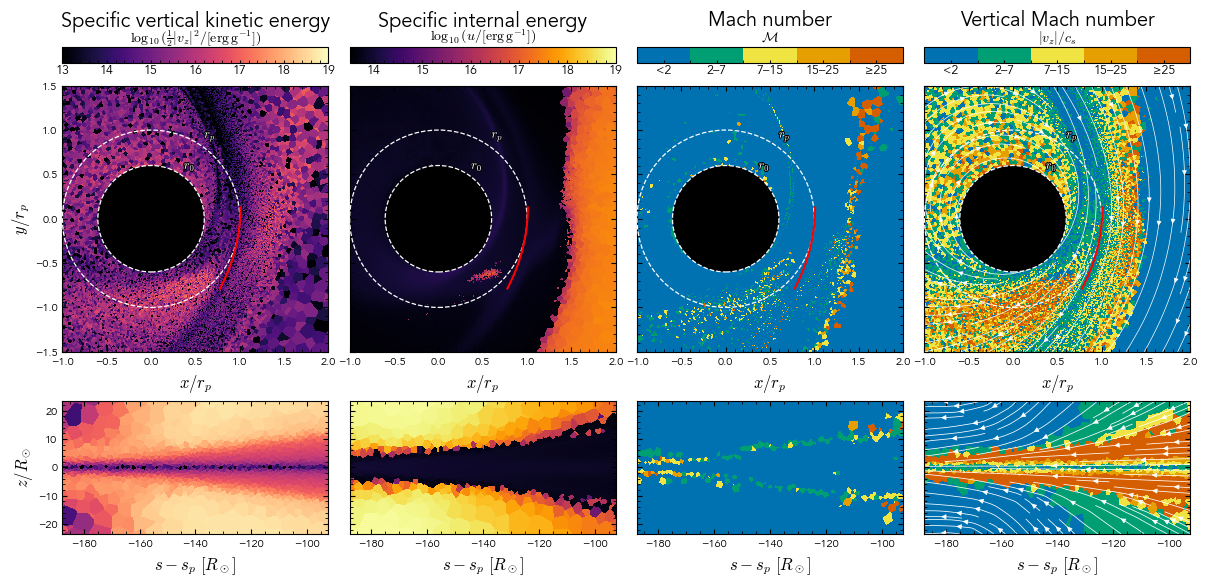

In [8]:
run = "1e6"
snapnum = SNAPSHOTS[run]

with np.load(
    SHOCK_ROOT / "mach-slices" / run / f"mach_P_snap_{snapnum:04d}.npz"
) as data:
    xy_mach = np.array(data["nozzle_xy_mach_P"])
with np.load(ZOOM_CACHES[run]) as data:
    time_tfb = float(data["time_tfb"])
    xy_x = np.array(data["nozzle_xy_x_rp"])
    xy_y = np.array(data["nozzle_xy_y_rp"])
    xy_vertical_kinetic = np.array(data["nozzle_xy_specific_vertical_kinetic"])
    xy_internal_energy = np.array(data["nozzle_xy_specific_internal_energy"])
    xy_vertical_mach = np.array(data["nozzle_xy_abs_vz_over_cs"])
    xy_vx = np.array(data["nozzle_xy_vx_kms"])
    xy_vy = np.array(data["nozzle_xy_vy_kms"])

    orbit_phi = np.array(data["nozzle_orbit_phi"])
    orbit_z = np.array(data["nozzle_orbit_z_rsun"])
    orbit_x = np.array(data["nozzle_orbit_x_rp"])
    orbit_y = np.array(data["nozzle_orbit_y_rp"])
    orbit_vertical_kinetic = np.array(
        data["nozzle_orbit_specific_vertical_kinetic"]
    )
    orbit_internal_energy = np.array(
        data["nozzle_orbit_specific_internal_energy"]
    )
    orbit_mach = np.array(data["nozzle_orbit_mach_P"])
    orbit_vertical_mach = np.array(data["nozzle_orbit_abs_vz_over_cs"])
    orbit_dphi = np.array(data["nozzle_orbit_dphi_dt"])
    orbit_dz = np.array(data["nozzle_orbit_dz_rsun_dt"])
    orbit_box_scale = float(data["nozzle_orbit_box_scale"])
    orbit_radius_scale = float(data["nozzle_orbit_radius_scale"])
    orbit_phase_deg = float(data["nozzle_orbit_phase_deg"])
with np.load(
    SHOCK_ROOT / "cells" / f"{run}_shock_cells_snap_{snapnum:04d}.npz"
) as data:
    r_p_rsun = float(data["r_p_rsun"])

orbit_s = np.concatenate(
    ([0.0], np.cumsum(np.hypot(np.diff(orbit_x), np.diff(orbit_y))))
) * r_p_rsun
orbit_s -= orbit_s[np.argmin(np.hypot(orbit_x, orbit_y))]
orbit_s -= ORBIT_S_SHIFT_RSUN[run]
orbit_ds = orbit_dphi * np.gradient(orbit_s, orbit_phi)[:, None]
orbit_s_stream = np.linspace(orbit_s[0], orbit_s[-1], orbit_s.size)
orbit_ds_stream = np.stack(
    [
        np.interp(orbit_s_stream, orbit_s, orbit_ds[:, column])
        for column in range(orbit_ds.shape[1])
    ],
    axis=1,
)
orbit_dz_stream = np.stack(
    [
        np.interp(orbit_s_stream, orbit_s, orbit_dz[:, column])
        for column in range(orbit_dz.shape[1])
    ],
    axis=1,
)

if MASK_SMOOTHING_REGION:
    smoothing_mask = np.hypot(xy_x[:, None], xy_y[None, :]) < SMOOTHING_RADIUS_RP
    xy_vertical_kinetic = np.where(smoothing_mask, np.nan, xy_vertical_kinetic)
    xy_internal_energy = np.where(smoothing_mask, np.nan, xy_internal_energy)
    xy_mach = np.where(smoothing_mask, np.nan, xy_mach)
    xy_vertical_mach = np.where(smoothing_mask, np.nan, xy_vertical_mach)
    xy_vx = np.where(smoothing_mask, np.nan, xy_vx)
    xy_vy = np.where(smoothing_mask, np.nan, xy_vy)

shared_limits = {
    "vertical_kinetic": logged_limits(
        np.concatenate((xy_vertical_kinetic.ravel(), orbit_vertical_kinetic.ravel())),
        ENERGY_DECADES,
    ),
    "internal_energy": logged_limits(
        np.concatenate((xy_internal_energy.ravel(), orbit_internal_energy.ravel())),
        ENERGY_DECADES,
    ),
    "mach": None,
    "vertical_mach": None,
}
fields = (
    (
        "vertical_kinetic",
        "Specific vertical kinetic energy",
        r"$\log_{10}(\frac{1}{2}|v_z|^2/[\mathrm{erg\,g^{-1}}])$",
        "magma",
    ),
    (
        "internal_energy",
        "Specific internal energy",
        r"$\log_{10}(u/[\mathrm{erg\,g^{-1}}])$",
        "inferno",
    ),
    ("mach", "Mach number", r"$\mathcal{M}$", MACH_CMAP),
    ("vertical_mach", "Vertical Mach number", r"$|v_z|/c_s$", MACH_CMAP),
)
xy_grids = {
    "vertical_kinetic": xy_vertical_kinetic,
    "internal_energy": xy_internal_energy,
    "mach": xy_mach,
    "vertical_mach": xy_vertical_mach,
}
orbit_grids = {
    "vertical_kinetic": orbit_vertical_kinetic,
    "internal_energy": orbit_internal_energy,
    "mach": orbit_mach,
    "vertical_mach": orbit_vertical_mach,
}

fig, axes = plt.subplots(
    2,
    4,
    figsize=FIGSIZE,
    gridspec_kw={"height_ratios": (2, 1), "wspace": 0.08, "hspace": 0.22},
)
for column, (name, title, label, cmap_name) in enumerate(fields):
    categorical = name in {"mach", "vertical_mach"}
    plot_cmap = plt.get_cmap(cmap_name).copy()
    plot_cmap.set_bad(EMPTY_SHOCK_COLOR if name == "mach" else MASK_COLOR)

    xy_grid = xy_grids[name]
    if categorical:
        xy_grid = mach_categories(xy_grid, shock_surface=name == "mach")
    _, xy_image = scalar_map(
        xy_grid,
        xy_x,
        xy_y,
        ax=axes[0, column],
        cmap=plot_cmap,
        colorbar_label=label,
        log_scale=False,
        aspect_equal=False,
        **(
            {"norm": MACH_NORM}
            if categorical
            else {
                "vmin": shared_limits[name][0],
                "vmax": shared_limits[name][1],
            }
        ),
        shading="auto",
        rasterized=True,
    )
    xy_image.colorbar.remove()
    compact_colorbar(fig, axes[0, column], xy_image, label)
    axes[0, column].set_title(title, pad=43)
    axes[0, column].set_box_aspect(1.0)
    axes[0, column].set_xlim(XY_WINDOW_RP[:2])
    axes[0, column].set_ylim(XY_WINDOW_RP[2:])
    if MASK_SMOOTHING_REGION:
        axes[0, column].add_patch(
            Circle(
                (0.0, 0.0),
                SMOOTHING_RADIUS_RP,
                facecolor=MASK_COLOR,
                edgecolor="none",
                zorder=8,
            )
        )
    axes[0, column].plot(orbit_x, orbit_y, **SLICE_LINE_STYLE)
    for radius, radius_label in REFERENCE_RADII:
        axes[0, column].add_patch(Circle((0.0, 0.0), radius, **RADIUS_STYLE))
        angle = np.deg2rad(55.0)
        axes[0, column].text(
            radius * np.cos(angle) + 0.025,
            radius * np.sin(angle) + 0.025,
            radius_label,
            color="white",
            fontsize=9,
            ha="left",
            va="bottom",
            path_effects=[
                path_effects.withStroke(linewidth=1.3, foreground="black")
            ],
            zorder=11,
        )

    orbit_grid = orbit_grids[name]
    if categorical:
        orbit_grid = mach_categories(orbit_grid, shock_surface=name == "mach")
    _, orbit_image = scalar_map(
        orbit_grid,
        orbit_s,
        orbit_z,
        ax=axes[1, column],
        cmap=plot_cmap,
        colorbar_label=label,
        log_scale=False,
        aspect_equal=False,
        **(
            {"norm": MACH_NORM}
            if categorical
            else {
                "vmin": shared_limits[name][0],
                "vmax": shared_limits[name][1],
            }
        ),
        shading="auto",
        rasterized=True,
    )
    orbit_image.colorbar.remove()
    axes[1, column].set_box_aspect(0.5)
    axes[1, column].set_xlim(float(orbit_s[0]), float(orbit_s[-1]))
    axes[1, column].set_ylim(float(orbit_z[0]), float(orbit_z[-1]))

axes[0, 3].streamplot(xy_x, xy_y, xy_vx.T, xy_vy.T, **XY_STREAMLINES)
axes[1, 3].streamplot(
    orbit_s_stream,
    orbit_z,
    orbit_ds_stream.T,
    orbit_dz_stream.T,
    **ORBIT_STREAMLINES,
)
for ax in axes[0]:
    ax.set_xlabel(r"$x/r_p$")
for ax in axes[1]:
    ax.set_xlabel(r"$s-s_p\ [R_\odot]$")
axes[0, 0].set_ylabel(r"$y/r_p$", labelpad=2)
axes[1, 0].set_ylabel(r"$z/R_\odot$", labelpad=2)
for ax in axes[:, 1:].flat:
    ax.tick_params(labelleft=False)
for ax in axes.flat:
    ax.tick_params(labelsize=8)

fig.subplots_adjust(left=0.055, right=0.995, bottom=0.08, top=0.86)
output = OUTPUT_ROOT / f"nozzle_energies_mach_{run}_snap_{snapnum:04d}.png"
fig.savefig(output, dpi=DPI, facecolor="white")
print(
    f"{run} M_sun | snap {snapnum} | t/t_fb={time_tfb:.4f} | "
    f"orbit box scale={orbit_box_scale:g}, radius scale={orbit_radius_scale:g}, "
    f"phase offset={orbit_phase_deg:+g} deg | {output}"
)
display(fig)
plt.close(fig)
